In [1]:
import os
os.chdir("..")
from qwen_vl import *
from autoencoder.model_qwen import QwenAutoencoder
from pathlib import Path
import umap as um
import PIL.Image as Image
import matplotlib.pyplot as plt

In [2]:
data_path = Path('data/hypernerf/chickchicken_qwen')
ae_ckpt_path = Path('autoencoder/ckpt/chickchicken_qwen_qwen/best_ckpt.pth')
lang_root = data_path / 'qwen_features'
img_name = '000047'
feature_path = lang_root / f'{img_name}_f.npy'
segment_path = lang_root / f'{img_name}_s.npy'

In [3]:
ae = QwenAutoencoder(latent_dim=3).to("cuda")
ae.load_state_dict(torch.load(ae_ckpt_path))
ae.eval()
pass

In [4]:
lf = torch.as_tensor(np.load(feature_path)).to("cuda")

In [5]:
latent_lf = ae.encode(lf)

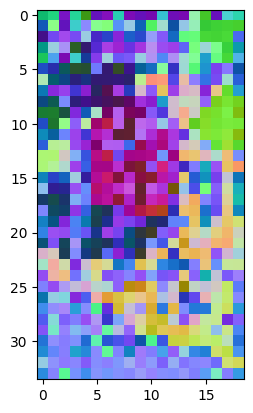

In [6]:
latent_lf_2d = patches_to_2d_from_hw(latent_lf, 952, 532)
plt.imshow(latent_lf_2d.detach().cpu() / 2 + 0.5)
plt.show()

In [7]:
model, processor = get_patched_qwen()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [11]:
print("raw")
print(ask_qwen_about_image_features(lf, "Describe this image.", model, processor, system_prompt="You are a helpful assistant who is able to concisely summarize visual scenes."))

raw
The image shows a person's hands holding an orange plastic container with a lid that has a face design on it, resembling a bird or chick. Inside the container is a yellow ball. The container appears to be designed for storing or protecting the ball. The scene takes place on a wooden cutting board, and there is another white ball in the background.


In [12]:
print("after ae")
thru_ae = ae.decode(ae.encode(lf))
print(ask_qwen_about_image_features(thru_ae, "Describe this image.", model, processor, system_prompt="You are a helpful assistant who is able to concisely summarize visual scenes."))

after ae
The image shows a person's hands holding an orange egg-shaped container with a lid that has a small opening. Inside the container, there is a yellow object resembling an egg with a face drawn on it. The container and its contents are placed on a wooden cutting board. In the background, there is another white egg-shaped object partially visible. The setting appears to be a kitchen or a similar environment.


In [25]:
def patches_to_2d_from_hw(patch_features: torch.Tensor, img_height: int, img_width: int):
    patches_width, patches_height = img_width // effective_patch_size, img_height // effective_patch_size
    return patch_features.reshape(patches_height, patches_width, -1)

In [13]:
umap = um.UMAP(n_components=3)
patch_features_umap = umap.fit_transform(lf.cpu().detach().to(torch.float32).numpy())
umap_scaler = MinMaxScaler((1e-4, 1-1e-4)) #type:ignore
patch_features_umap = umap_scaler.fit_transform(patch_features_umap) #type:ignore
patch_features_umap_2d = patches_to_2d_from_hw(patch_features_umap, 952, 532)

/home/tumai/miniconda3/envs/rn4ds/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


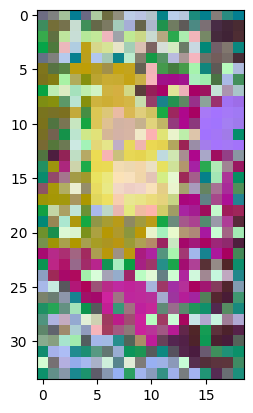

In [14]:
plt.imshow(patch_features_umap_2d)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.006756574..1.0224652].


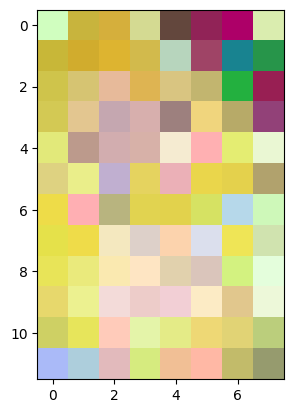

In [15]:
cx1, cx2 = 5, 12
cy1, cy2 = 7, 18
cropped_patch_features = crop_patch_features(lf, 19, 34, cx1, cx2, cy1, cy2)
cropped_patch_features_umap = umap.transform(cropped_patch_features.cpu().to(torch.float32))
cropped_patch_features_umap = umap_scaler.transform(cropped_patch_features_umap).reshape(cy2-cy1+1, cx2-cx1+1, -1)
plt.imshow(cropped_patch_features_umap)
plt.show()

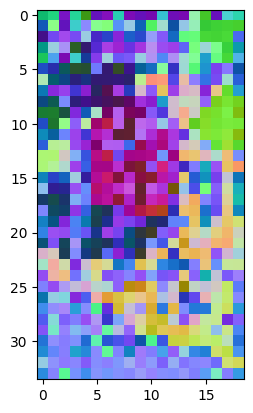

In [31]:
plt.imshow(latent_lf_2d.detach().cpu() / 2 + 0.5)
plt.show()

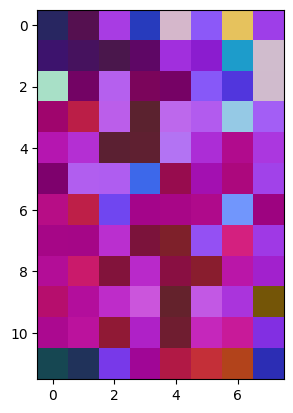

In [13]:
# cx1, cx2 = 8, 8
# cy1, cy2 = 13, 13
cx1, cx2 = 5, 12
cy1, cy2 = 7, 18
cropped_patch_features = crop_patch_features(lf, 19, 34, cx1, cx2, cy1, cy2)
plt.imshow(ae.encode(cropped_patch_features).reshape(cy2-cy1+1, cx2-cx1+1, -1).detach().cpu() / 2. + 0.5)
plt.show()

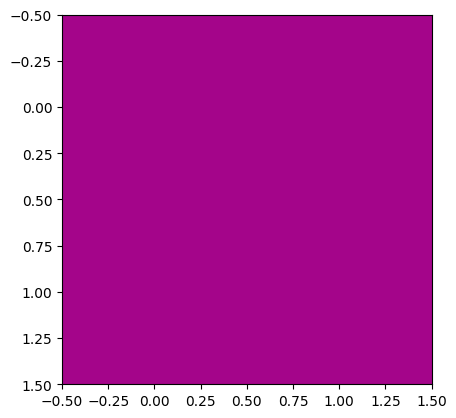

In [45]:
# Extra for 1px image:
cropped_patch_features = cropped_patch_features.expand(4, -1)
plt.imshow(ae.encode(cropped_patch_features).reshape(2, 2, -1).detach().cpu() / 2. + 0.5)
plt.show()

In [50]:
print("cropped raw")
print(ask_qwen_about_image_features(cropped_patch_features, "Describe this image.", system_prompt="You are a helpful assistant."))

cropped raw
The image shows a red, heart-shaped container with a yellow egg inside it. The container appears to be designed for holding the egg securely, as it has a lid that is currently open. The egg has a small face drawn on it, giving it a playful appearance. The container and egg are placed on a wooden surface, likely a cutting board or table. A person's hand is visible, holding the lid of the container, suggesting they are either opening or closing it.


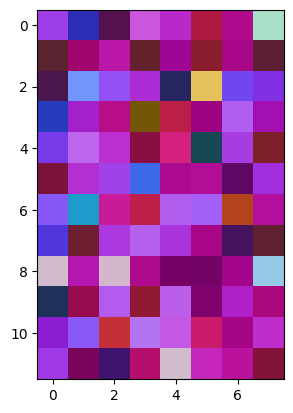

In [14]:
# Shuffling the patch features
idx = torch.randperm(cropped_patch_features.shape[0])
cropped_patch_features_shuffled = cropped_patch_features[idx]
plt.imshow(ae.encode(cropped_patch_features_shuffled).reshape(cy2-cy1+1, cx2-cx1+1, -1).detach().cpu() / 2. + 0.5)
plt.show()

In [15]:
print("cropped shuffled")
print(ask_qwen_about_image_features(cropped_patch_features_shuffled, "Describe this image.", model, processor, system_prompt="You are a helpful assistant who is able to concisely summarize visual scenes."))

cropped shuffled
The image shows a red, egg-shaped container with a lid that has a face drawn on it, resembling a chick or bird. The lid is open, revealing a yellow, spherical object inside the container. The container appears to be made of plastic and is placed on a wooden surface. A hand is visible in the background, suggesting someone is interacting with the container.


In [ ]:
print("cropped after ae")
cropped_thru_ae = ae.decode(ae.encode(cropped_patch_features))
print(ask_qwen_about_image_features(cropped_thru_ae, "Describe this image."))

cropped after ae
The image shows a red plastic egg-shaped container with a face design on it, which is open to reveal a yellow object inside that also has a face design. The container appears to be designed for holding small items, possibly as a novelty or decorative item.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.034991413..1.0294482].


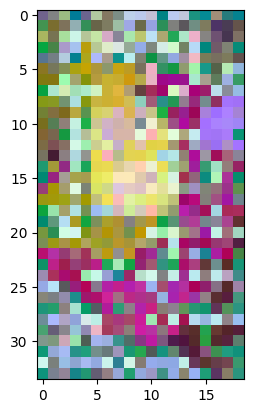

In [23]:
thru_ae_umap = umap_scaler.transform(umap.transform(thru_ae.cpu().detach().to(torch.float32).numpy()))
thru_ae_umap_2d = patches_to_2d_from_hw(thru_ae_umap, 952, 532)
plt.imshow(thru_ae_umap_2d)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023084372..1.0213909].


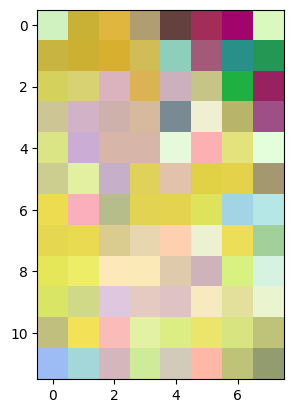

In [25]:
cropped_thru_ae_2d = crop_patch_features(torch.as_tensor(thru_ae_umap), 19, 34, cx1, cx2, cy1, cy2).reshape(cy2-cy1+1, cx2-cx1+1, -1)
plt.imshow(cropped_thru_ae_2d)
plt.show()